In [1]:
# [CELDA 1] - Importaciones
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization as vis
from datetime import datetime
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import your utilities and constants
from utils.model_utils import open_best_model, get_best_model_name, save_optimized_model
from constants import (
    X_train, X_train_scaled,
    y_train, y_train_scaled
)

c:\Projects\Espol\machine-learning-project\machine_learning_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [CELDA 2] - Funciones auxiliares (versión corregida)
def is_scaled_model(model_name: str) -> bool:
    """Determine if the model uses scaled data based on its name."""
    scaled_models = ['rf4', 'rf5', 'rf6', 'lr2']
    return any(name in model_name for name in scaled_models)

def print_progress_callback(study, trial):
    """Callback para mostrar progreso detallado."""
    elapsed_time = datetime.now() - study.user_attrs["start_time"]
    completed_trials = len(study.get_trials(states=[optuna.trial.TrialState.COMPLETE]))
    
    if trial.number == 0:
        study.set_user_attr("first_value", trial.value)
        improvement = 0.0
    else:
        first_value = study.user_attrs.get("first_value", trial.value)
        improvement = ((trial.value - first_value) / abs(first_value) * 100)
    
    print(f"\nPrueba {trial.number}:")
    print(f"  Valor: {trial.value:.4f}")
    print(f"  Tiempo transcurrido: {elapsed_time}")
    print(f"  Pruebas completadas: {completed_trials}/{study.user_attrs['n_trials']}")
    print(f"  Mejor valor hasta ahora: {study.best_value:.4f}")
    if trial.number > 0:  # Solo mostrar mejora después de la primera prueba
        print(f"  Mejora sobre primera prueba: {improvement:.2f}%")

In [3]:
# [CELDA 3] - Funciones objetivo optimizadas
def objective_rf_fast(trial, X, y):
    """Función objetivo optimizada para Random Forest."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 10, 13),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'n_jobs': -1,
        'random_state': 42,
        'warm_start': True
    }
    
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X, y, cv=5, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

def objective_lr_fast(trial, X, y):
    """Función objetivo optimizada para Logistic Regression."""
    params = {
        'C': trial.suggest_loguniform('C', 1e-4, 1e4),
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'solver': trial.suggest_categorical('solver', ['saga']),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2'])
    }
    
    model = LogisticRegression(**params, random_state=42)
    scores = cross_val_score(model, X, y, cv=3, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

In [4]:
# [CELDA 4] - Carga y preparación de datos
# Cargar el mejor modelo
best_model = open_best_model()
print("Best model information:")
print(f"Model type: {type(best_model).__name__}")

# Determinar el tipo de datos a usar
model_name = get_best_model_name()
print("model_name", model_name)
use_scaled_data = is_scaled_model(model_name)

# Seleccionar los datos apropiados
if use_scaled_data:
    print("Using scaled data for optimization")
    X = X_train_scaled
    y = y_train_scaled.values.ravel()
else:
    print("Using original (unscaled) data for optimization")
    X = X_train
    y = y_train.values.ravel()

Best model information:
Model type: RandomForestClassifier
model_name optimized_rf_scaled
Using original (unscaled) data for optimization


In [5]:
# [CELDA 5] - Configuración del estudio
# Configurar el estudio de optimización
sampler = TPESampler(
    n_startup_trials=5,
    multivariate=True,
    seed=42
)

pruner = MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=5,
    interval_steps=1
)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)

# Configurar parámetros
n_trials = 5  # Reducido para mayor velocidad
timeout = 1800  # 30 minutos máximo

# Importante: Establecer el tiempo de inicio ANTES de la optimización
study.set_user_attr("start_time", datetime.now())
study.set_user_attr("n_trials", n_trials)

# Seleccionar la función objetivo apropiada
if isinstance(best_model, RandomForestClassifier):
    objective = lambda trial: objective_rf_fast(trial, X, y)
    print("Optimizing RandomForest model")
else:
    objective = lambda trial: objective_lr_fast(trial, X, y)
    print("Optimizing LogisticRegression model")

[I 2025-04-29 03:48:21,839] A new study created in memory with name: no-name-5d3d91b4-cdc0-4f3f-9f7f-dae7c2e7fd19


Optimizing RandomForest model


In [6]:
# [CELDA 6] - Ejecución de la optimización
try:
    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        callbacks=[print_progress_callback],
        n_jobs=-1,
        gc_after_trial=True,
        show_progress_bar=True
    )
except KeyboardInterrupt:
    print("\nOptimización interrumpida por el usuario.")
finally:
    # Imprimir resultados finales
    print("\nResultados de la Optimización")
    print("=" * 50)
    print(f"Número de pruebas completadas: {len(study.trials)}")
    print(f"\nMejor prueba:")
    trial = study.best_trial
    print(f"  Valor: {trial.value:.4f}")
    print("\n  Parámetros:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    # Usar get() para evitar KeyError
    start_time = study.user_attrs.get("start_time")
    if start_time is not None:
        total_time = datetime.now() - start_time
        print(f"\nTiempo total de optimización: {total_time}")
    
    # Calcular mejora total si hay más de una prueba
    if len(study.trials) > 1:
        first_value = study.user_attrs.get("first_value")
        if first_value is not None:
            total_improvement = ((study.best_value - first_value) / abs(first_value) * 100)
            print(f"Mejora total: {total_improvement:.2f}%")

Best trial: 0. Best value: 0.888115:   0%|          | 0/5 [01:27<?, ?it/s]

[I 2025-04-29 03:49:49,075] Trial 0 finished with value: 0.8881151592674081 and parameters: {'n_estimators': 263, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8881151592674081.

Prueba 0:
  Valor: 0.8881
  Tiempo transcurrido: 0:01:27.903092
  Pruebas completadas: 1/5
  Mejor valor hasta ahora: 0.8881


Best trial: 0. Best value: 0.888115:  20%|██        | 1/5 [01:59<05:51, 87.89s/it, 87.89/1800 seconds]

[I 2025-04-29 03:50:20,878] Trial 4 finished with value: 0.8879357623575898 and parameters: {'n_estimators': 117, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8881151592674081.


Best trial: 0. Best value: 0.888115:  40%|████      | 2/5 [01:59<02:44, 54.69s/it, 119.34/1800 seconds]

...

[I 2025-04-29 03:51:25,242] Trial 2 finished with value: 0.8880253065723552 and parameters: {'n_estimators': 155, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.8881151592674081.


Best trial: 0. Best value: 0.888115:  80%|████████  | 4/5 [03:05<00:42, 42.13s/it, 185.18/1800 seconds]


Prueba 2:
  Valor: 0.8880
  Tiempo transcurrido: 0:03:05.193506
  Pruebas completadas: 4/5
  Mejor valor hasta ahora: 0.8881
  Mejora sobre primera prueba: -0.01%


Best trial: 0. Best value: 0.888115: 100%|██████████| 5/5 [03:18<00:00, 39.62s/it, 198.11/1800 seconds]

[I 2025-04-29 03:51:39,892] Trial 3 finished with value: 0.8872666945549927 and parameters: {'n_estimators': 219, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.8881151592674081.

Prueba 3:
  Valor: 0.8873
  Tiempo transcurrido: 0:03:18.121371
  Pruebas completadas: 5/5
  Mejor valor hasta ahora: 0.8881
  Mejora sobre primera prueba: -0.10%

Resultados de la Optimización
Número de pruebas completadas: 5

Mejor prueba:
  Valor: 0.8881

  Parámetros:
    n_estimators: 263
    max_depth: 11
    min_samples_split: 8
    min_samples_leaf: 3
    max_features: log2
    class_weight: balanced

Tiempo total de optimización: 0:03:18.131221
Mejora total: 0.00%


In [7]:
# [CELDA 7] - Creación y guardado del modelo final
# Crear y entrenar el modelo final con los mejores parámetros
if isinstance(best_model, RandomForestClassifier):
    optimized_model = RandomForestClassifier(**study.best_trial.params, random_state=42)
else:
    optimized_model = LogisticRegression(**study.best_trial.params, random_state=42)

# Entrenar el modelo optimizado
optimized_model.fit(X, y)

# Guardar el modelo optimizado
model_name = 'optimized_rf' if isinstance(best_model, RandomForestClassifier) else 'optimized_lr'
model_name = f"{model_name}_scaled" if use_scaled_data else model_name
save_optimized_model(optimized_model, model_name)
print(f"\nModelo optimizado guardado como: {model_name}")


Modelo optimizado guardado como: optimized_rf


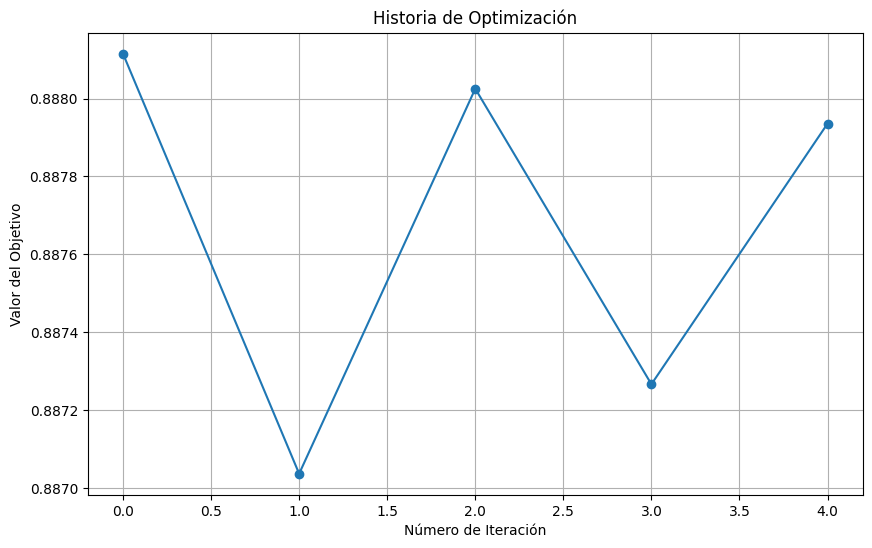

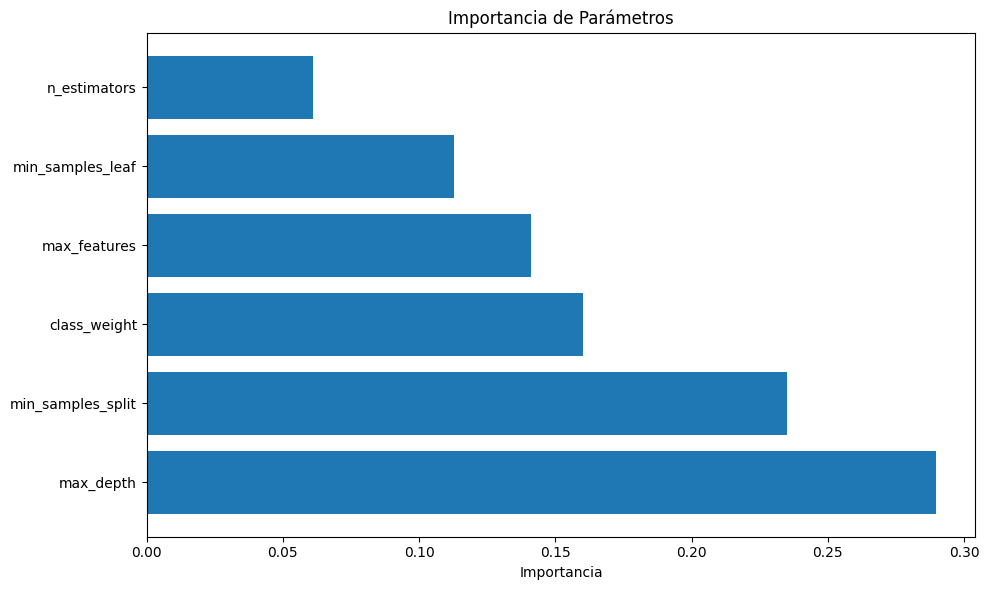

In [8]:
# [CELDA 8] - Visualización de resultados (usando matplotlib)
import matplotlib.pyplot as plt
import numpy as np

# Graficar la historia de optimización
plt.figure(figsize=(10, 6))
trials = study.trials
values = [t.value for t in trials if t.value is not None]
iterations = list(range(len(values)))

plt.plot(iterations, values, marker='o')
plt.xlabel('Número de Iteración')
plt.ylabel('Valor del Objetivo')
plt.title('Historia de Optimización')
plt.grid(True)
plt.show()

# Graficar importancia de parámetros (versión simplificada)
if len(study.trials) > 1:
    plt.figure(figsize=(10, 6))
    importance = optuna.importance.get_param_importances(study)
    
    # Ordenar por importancia
    sorted_importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))
    
    # Crear gráfico de barras
    plt.barh(list(sorted_importance.keys()), list(sorted_importance.values()))
    plt.xlabel('Importancia')
    plt.title('Importancia de Parámetros')
    plt.tight_layout()
    plt.show()